# Phase 2: 10-Class MNIST Classification — Linear SVM (One-vs-Rest)
## Pipeline: Data Loading -> Preprocessing -> PCA -> Training -> CV Tuning -> Learning Curves -> Evaluation

## 1. Setup & Imports

In [18]:
import sys, os
sys.path.append('..')
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from ml_utils import train_test_split, StandardScaler
from ml_utils import classification_report, confusion_matrix, evaluate_model, show_misclassified, plot_learning_curve
from sklearn.decomposition import PCA
from skimage.feature import hog
np.random.seed(42)
print("Libraries imported")

Libraries imported


## 2. Configuration

In [3]:
NUM_CLASSES = 10
TRAIN_SIZE, VAL_SIZE, TEST_SIZE = 0.70, 0.15, 0.15
PCA_VARIANCE = 0.95
K_FOLDS = 5
LC_FRACTIONS = [0.1, 0.2, 0.3, 0.5, 0.7, 1.0]
SVM_LR = 0.001
SVM_LAMBDA = 0.01
SVM_ITER = 200

## 3. Data Loading & Preprocessing

In [4]:
X_train_raw = np.load('../../mnist.npz/x_train.npy')
y_train_raw = np.load('../../mnist.npz/y_train.npy')
X_test_raw  = np.load('../../mnist.npz/x_test.npy')
y_test_raw  = np.load('../../mnist.npz/y_test.npy')
X_all = np.concatenate([X_train_raw, X_test_raw], axis=0)
y_all = np.concatenate([y_train_raw, y_test_raw], axis=0)

min_count = min(np.bincount(y_all))
balanced_idx = []
for c in range(NUM_CLASSES):
    c_idx = np.where(y_all == c)[0]
    np.random.shuffle(c_idx)
    balanced_idx.extend(c_idx[:min_count])
balanced_idx = np.array(balanced_idx)
np.random.shuffle(balanced_idx)
X_balanced, y_balanced = X_all[balanced_idx], y_all[balanced_idx]
X_norm = X_balanced / 255.0

X_temp, X_test, y_temp, y_test = train_test_split(
    X_norm, y_balanced, test_size=TEST_SIZE/(TRAIN_SIZE+VAL_SIZE+TEST_SIZE),
    random_state=42, stratify=y_balanced)
val_adj = VAL_SIZE / (TRAIN_SIZE + VAL_SIZE)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=val_adj, random_state=42, stratify=y_temp)
print(f"Train: {X_train.shape[0]}, Val: {X_val.shape[0]}, Test: {X_test.shape[0]}")

Train: 44190, Val: 9470, Test: 9470


### Visualise Dataset Samples
One example per class from the training set.

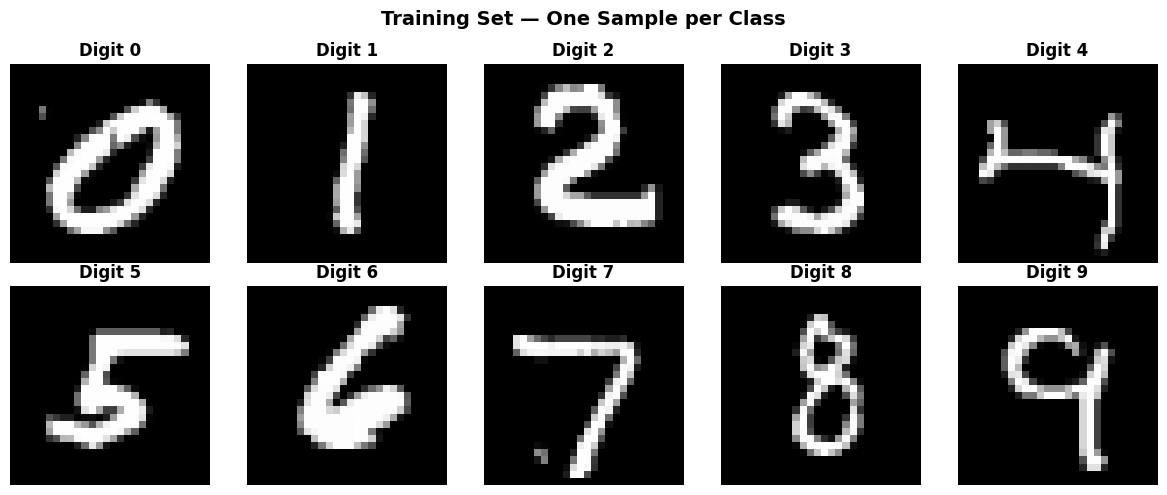

In [5]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for c in range(NUM_CLASSES):
    r, col = divmod(c, 5)
    idx = np.where(y_train == c)[0][0]
    axes[r, col].imshow(X_train[idx], cmap='gray')
    axes[r, col].set_title(f'Digit {c}', fontweight='bold')
    axes[r, col].axis('off')
plt.suptitle('Training Set — One Sample per Class', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

## 4a. Flatten + Scaler + PCA Feature Extraction

In [6]:
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_val_flat = X_val.reshape(X_val.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_flat)
X_val_sc = scaler.transform(X_val_flat)
X_test_sc = scaler.transform(X_test_flat)
pca = PCA(n_components=PCA_VARIANCE, svd_solver='full')
X_train_pca = pca.fit_transform(X_train_sc)
X_val_pca = pca.transform(X_val_sc)
X_test_pca = pca.transform(X_test_sc)
print(f"PCA: {X_train_sc.shape[1]} → {X_train_pca.shape[1]} components ({np.sum(pca.explained_variance_ratio_):.4f} var)")

PCA: 784 → 324 components (0.9503 var)


### Visualise PCA

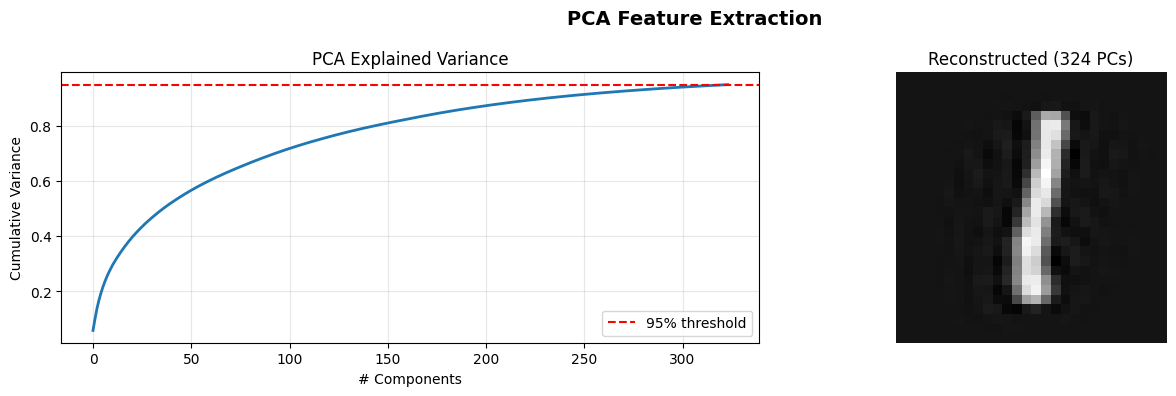

In [7]:
cum_var = np.cumsum(pca.explained_variance_ratio_)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(cum_var, linewidth=2)
axes[0].axhline(PCA_VARIANCE, ls='--', color='red', label=f'{PCA_VARIANCE:.0%} threshold')
axes[0].set_xlabel('# Components'); axes[0].set_ylabel('Cumulative Variance')
axes[0].set_title('PCA Explained Variance'); axes[0].legend(); axes[0].grid(alpha=.3)

recon = pca.inverse_transform(X_train_pca[0:1])
recon = scaler.inverse_transform(recon).reshape(28, 28)
axes[1].imshow(recon, cmap='gray')
axes[1].set_title(f'Reconstructed ({X_train_pca.shape[1]} PCs)'); axes[1].axis('off')
plt.suptitle('PCA Feature Extraction', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

## 4b. HOG Feature Extraction

**Histogram of Oriented Gradients** captures edge and gradient structure.
Applied to the 2D images (before flattening), then standardised.

In [8]:
def extract_hog(images):
    feats = []
    for img in images:
        f = hog(img, orientations=9, pixels_per_cell=(4,4),
                cells_per_block=(2,2), block_norm='L2-Hys')
        feats.append(f)
    return np.array(feats)

X_train_hog = extract_hog(X_train)
X_val_hog   = extract_hog(X_val)
X_test_hog  = extract_hog(X_test)

scaler_hog = StandardScaler()
X_train_hog_sc = scaler_hog.fit_transform(X_train_hog)
X_val_hog_sc   = scaler_hog.transform(X_val_hog)
X_test_hog_sc  = scaler_hog.transform(X_test_hog)

print(f"HOG feature dim: {X_train_hog_sc.shape[1]}")
print("HOG features ready")

HOG feature dim: 1296
HOG features ready


### Visualise HOG Features

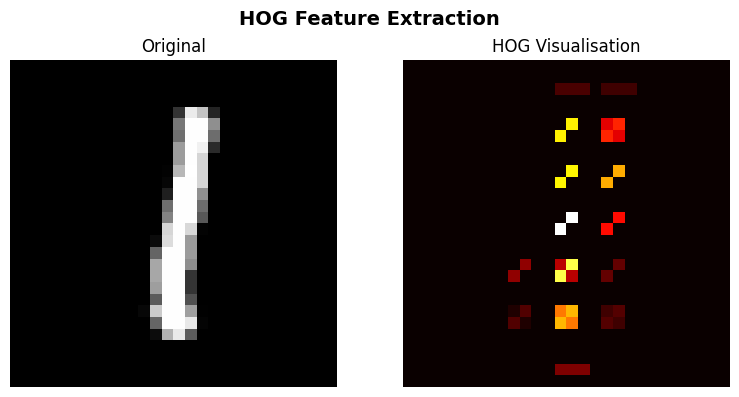

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(X_train[0], cmap='gray')
axes[0].set_title('Original'); axes[0].axis('off')
_, hog_img = hog(X_train[0], orientations=9, pixels_per_cell=(4,4),
                 cells_per_block=(2,2), block_norm='L2-Hys', visualize=True)
axes[1].imshow(hog_img, cmap='hot')
axes[1].set_title('HOG Visualisation'); axes[1].axis('off')
plt.suptitle('HOG Feature Extraction', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

## 6. Linear SVM Model (One-vs-Rest, Hinge Loss)

$$L_i = \max(0, 1 - y_i(\mathbf{w}\cdot\mathbf{x}_i + b))$$

In [10]:
class LinearSVM:
    def __init__(self, learning_rate=0.001, lambda_param=0.01, n_iterations=200):
        self.lr = learning_rate
        self.lam = lambda_param
        self.n_iter = n_iterations
        self.models = []

    def fit(self, X, y):
        n, d = X.shape
        self.classes_ = np.unique(y)
        self.models = []
        for c in self.classes_:
            yb = np.where(y == c, 1, -1)
            w, b = np.zeros(d), 0.0
            for _ in range(self.n_iter):
                for i in range(n):
                    if yb[i] * (X[i] @ w + b) >= 1:
                        w -= self.lr * (self.lam * w)
                    else:
                        w -= self.lr * (self.lam * w - yb[i] * X[i])
                        b -= self.lr * (-yb[i])
            self.models.append((w, b))
        return self

    def predict(self, X):
        scores = np.column_stack([X @ w + b for w, b in self.models])
        return self.classes_[np.argmax(scores, axis=1)]

## 7. Baseline Training

> **Note:** SVM with SGD on full data is slow. Using reduced iterations. (PCA Features)

BASELINE LINEAR SVM

Linear SVM Baseline — Test Acc: 0.9071 (90.71%)
                 precision     recall   f1-score    support

        Digit 0       0.95       0.97       0.96        947
        Digit 1       0.94       0.96       0.95        947
        Digit 2       0.88       0.91       0.90        947
        Digit 3       0.88       0.87       0.87        947
        Digit 4       0.91       0.93       0.92        947
        Digit 5       0.89       0.88       0.88        947
        Digit 6       0.91       0.95       0.93        947
        Digit 7       0.91       0.93       0.92        947
        Digit 8       0.89       0.83       0.86        947
        Digit 9       0.91       0.85       0.88        947

       accuracy                             0.91       9470
      macro avg       0.91       0.91       0.91       9470
   weighted avg       0.91       0.91       0.91       9470



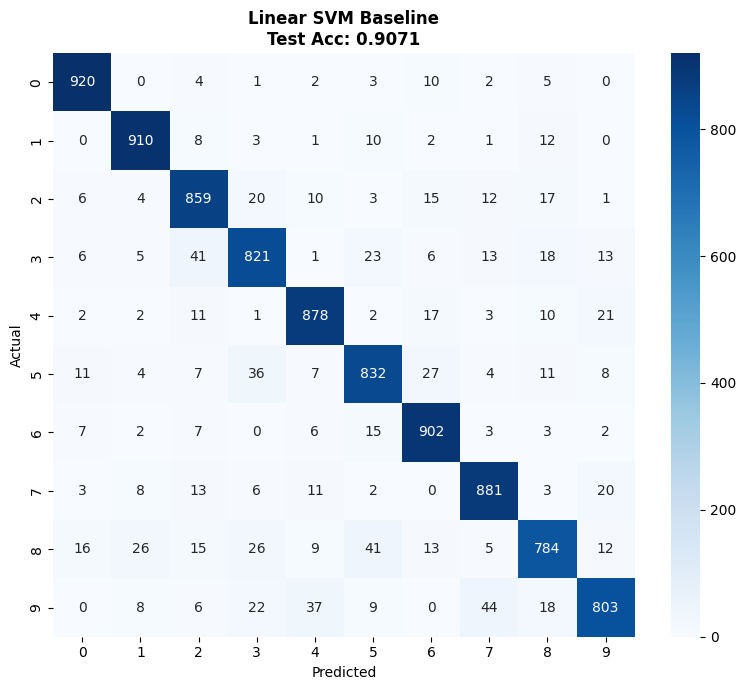

In [11]:
print("BASELINE LINEAR SVM")
svm_base = LinearSVM(learning_rate=SVM_LR, lambda_param=SVM_LAMBDA, n_iterations=SVM_ITER)
svm_base.fit(X_train_pca, y_train)
base_acc = evaluate_model(svm_base, X_test_pca, y_test, "Linear SVM Baseline")

Misclassified: 880 / 9470


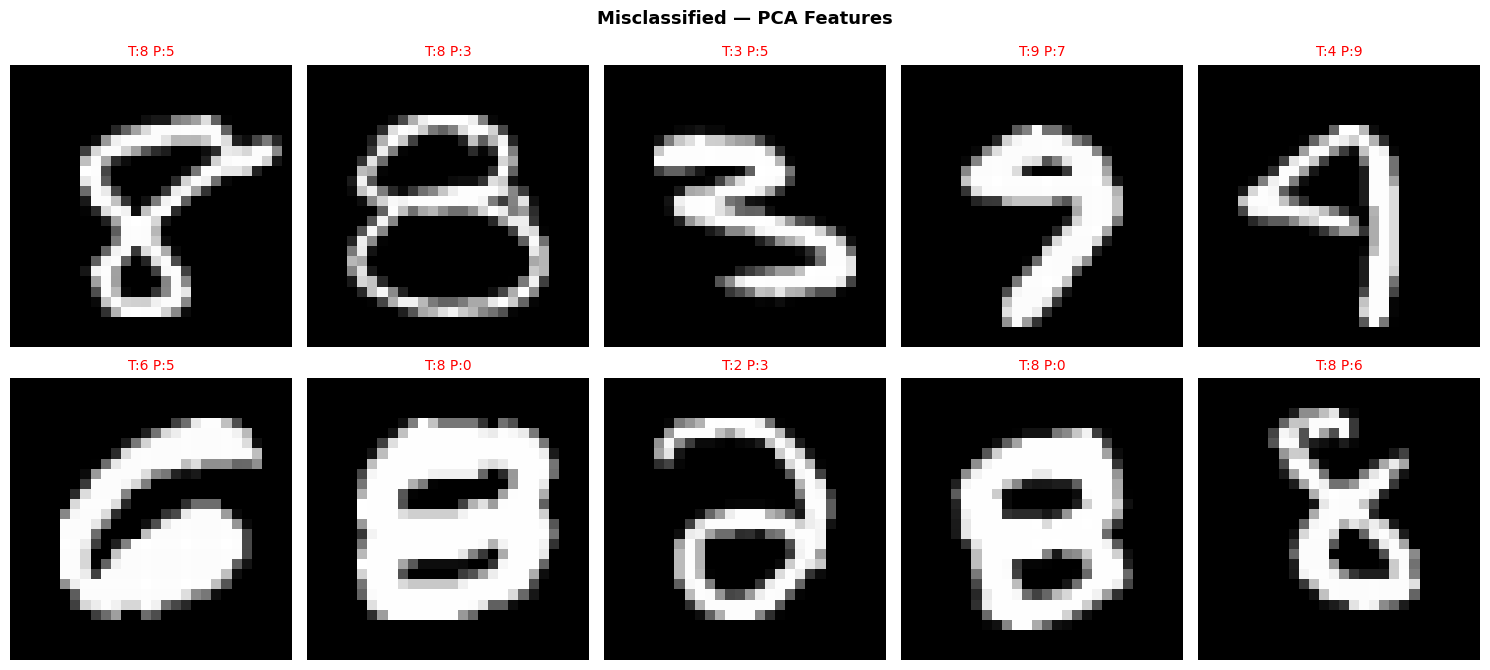

In [12]:
# Note: showing original images for misclassified PCA predictions
preds_pca = svm_base.predict(X_test_pca)
show_misclassified(y_test, preds_pca, X_test,
                   title='Misclassified — PCA Features')

### Linear SVM — Flatten Features


Linear SVM — Flatten Features

Linear SVM (Flatten) — Test Acc: 0.9059 (90.59%)
                 precision     recall   f1-score    support

        Digit 0       0.94       0.97       0.96        947
        Digit 1       0.94       0.96       0.95        947
        Digit 2       0.89       0.90       0.90        947
        Digit 3       0.88       0.87       0.88        947
        Digit 4       0.92       0.93       0.92        947
        Digit 5       0.87       0.88       0.88        947
        Digit 6       0.90       0.95       0.92        947
        Digit 7       0.91       0.92       0.92        947
        Digit 8       0.90       0.82       0.86        947
        Digit 9       0.91       0.85       0.88        947

       accuracy                             0.91       9470
      macro avg       0.91       0.91       0.91       9470
   weighted avg       0.91       0.91       0.91       9470



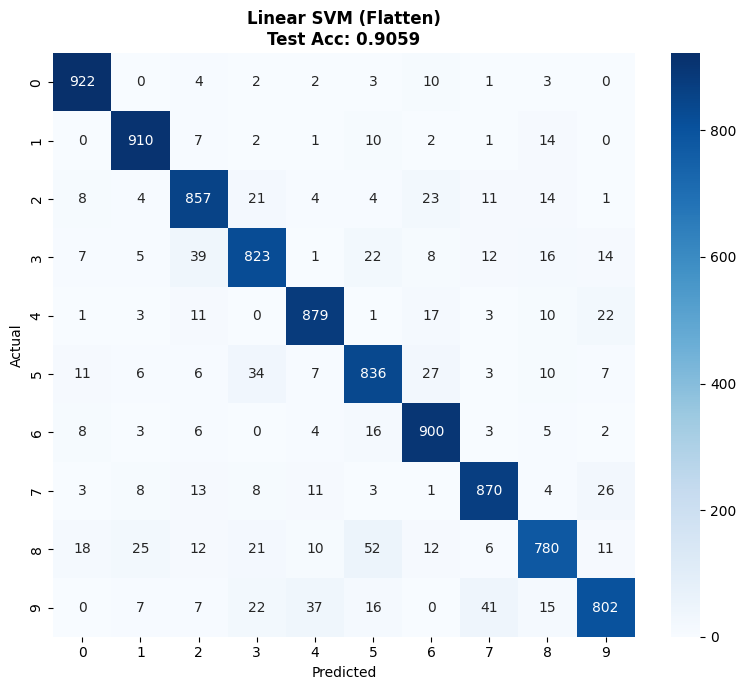

np.float64(0.9059134107708553)

In [13]:
print("\n" + "="*70)
print("Linear SVM — Flatten Features")
print("="*70)
model_flatten = LinearSVM(learning_rate=SVM_LR, lambda_param=SVM_LAMBDA, n_iterations=SVM_ITER)
model_flatten.fit(X_train_sc, y_train)
evaluate_model(model_flatten, X_test_sc, y_test, "Linear SVM (Flatten)")

Misclassified: 891 / 9470


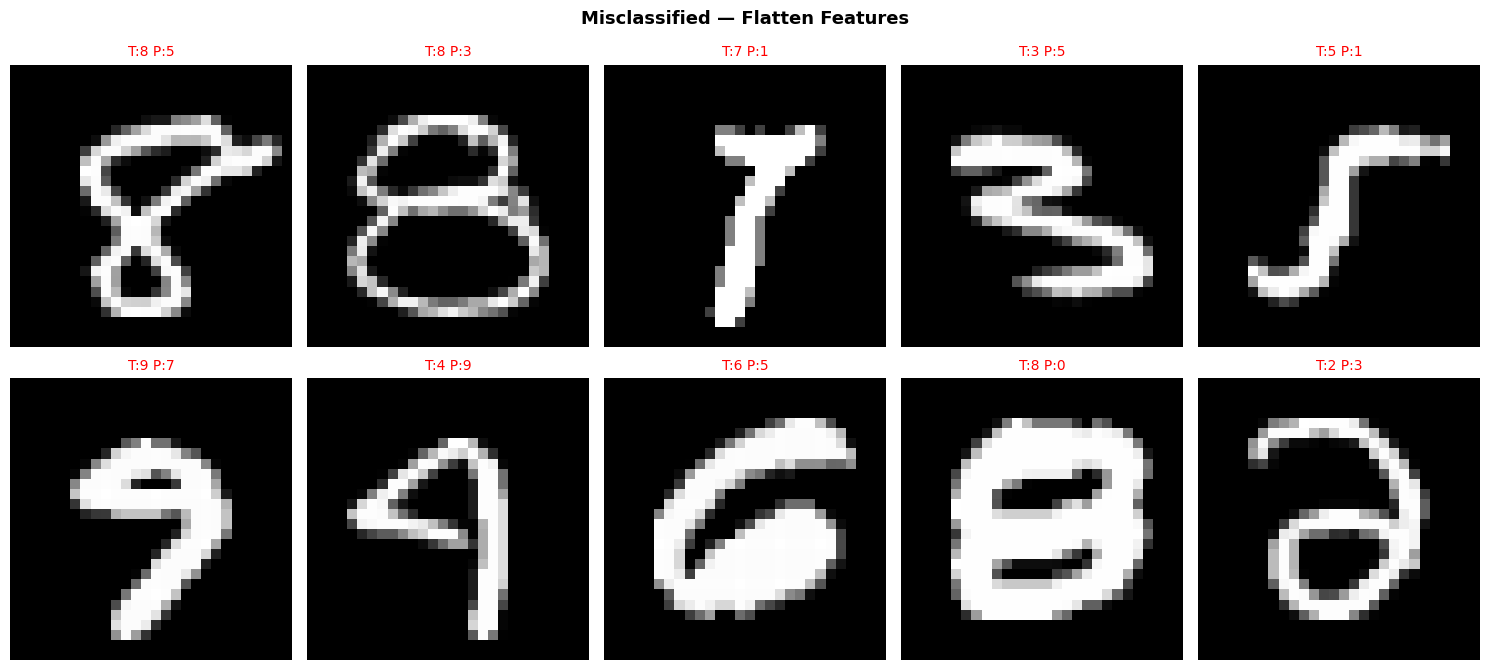

In [14]:
# Note: showing original images for misclassified Flatten predictions
preds_flatten = model_flatten.predict(X_test_sc)
show_misclassified(y_test, preds_flatten, X_test,
                   title='Misclassified — Flatten Features')

### Linear SVM — HOG Features


Linear SVM — HOG Features

Linear SVM (HOG) — Test Acc: 0.9755 (97.55%)
                 precision     recall   f1-score    support

        Digit 0       0.98       0.99       0.98        947
        Digit 1       0.98       0.99       0.98        947
        Digit 2       0.97       0.98       0.98        947
        Digit 3       0.97       0.97       0.97        947
        Digit 4       0.97       0.98       0.98        947
        Digit 5       0.98       0.98       0.98        947
        Digit 6       0.98       0.99       0.98        947
        Digit 7       0.98       0.98       0.98        947
        Digit 8       0.97       0.95       0.96        947
        Digit 9       0.98       0.95       0.97        947

       accuracy                             0.98       9470
      macro avg       0.98       0.98       0.98       9470
   weighted avg       0.98       0.98       0.98       9470



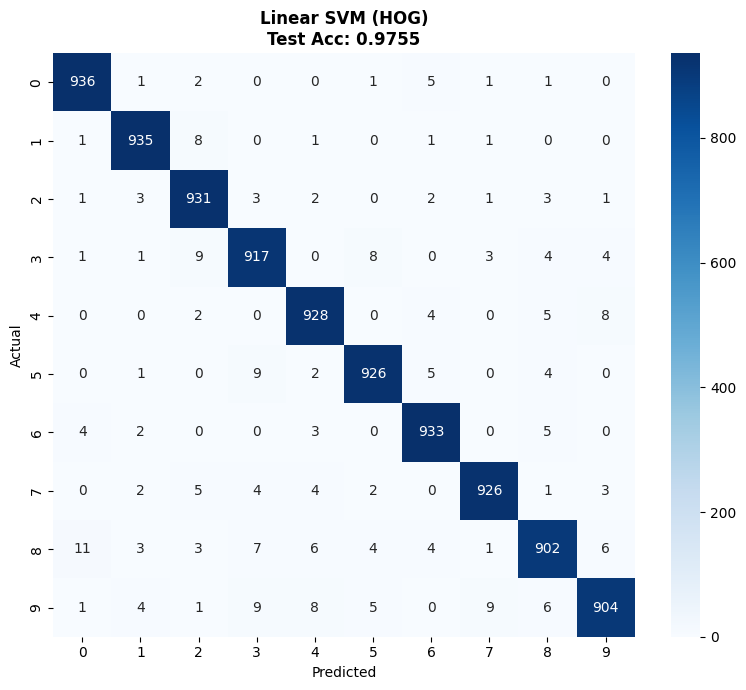

np.float64(0.9755015839493136)

In [15]:
print("\n" + "="*70)
print("Linear SVM — HOG Features")
print("="*70)
model_hog = LinearSVM(learning_rate=SVM_LR, lambda_param=SVM_LAMBDA, n_iterations=SVM_ITER)
model_hog.fit(X_train_hog_sc, y_train)
evaluate_model(model_hog, X_test_hog_sc, y_test, "Linear SVM (HOG)")

Misclassified: 232 / 9470


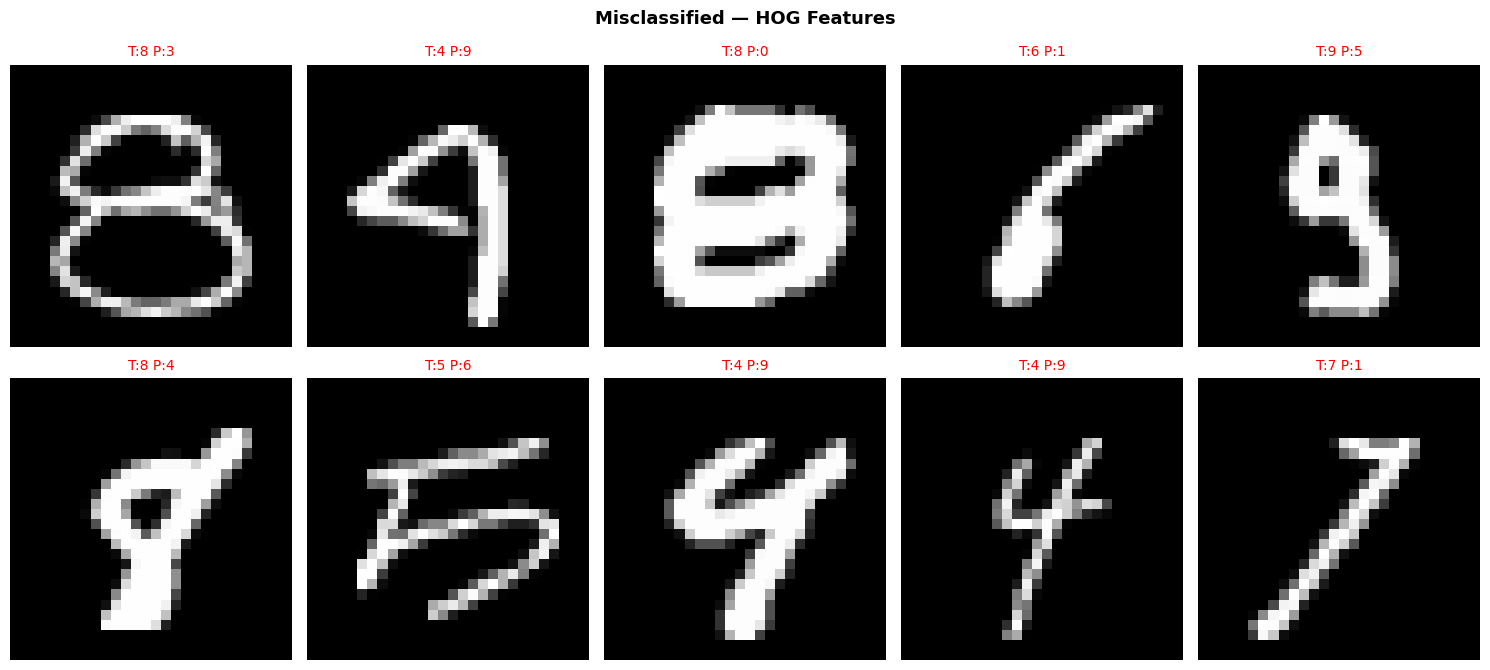

In [16]:
# Note: showing original images for misclassified HOG predictions
preds_hog = model_hog.predict(X_test_hog_sc)
show_misclassified(y_test, preds_hog, X_test,
                   title='Misclassified — HOG Features')

## 8. Learning Curve

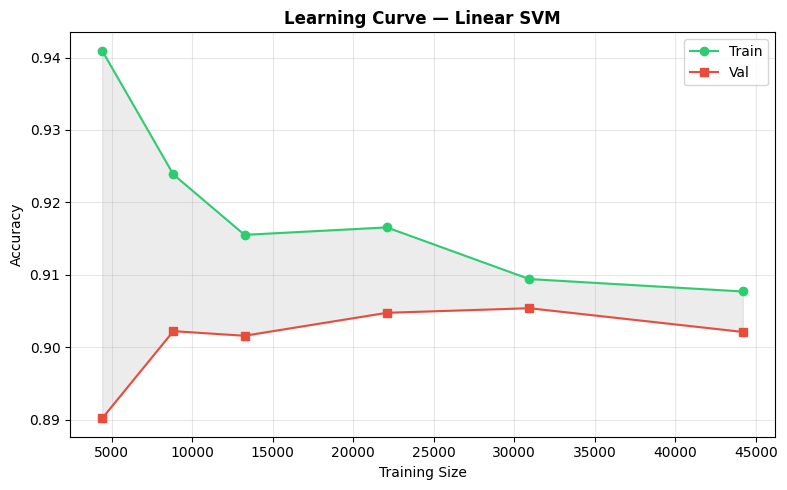

In [19]:
plot_learning_curve(LinearSVM, {'learning_rate': SVM_LR, 'lambda_param': SVM_LAMBDA, 'n_iterations': SVM_ITER},
                    X_train_pca, y_train, X_val_pca, y_val, LC_FRACTIONS,
                    "Learning Curve — Linear SVM")

## 9. Summary

**Analysis**: The linear SVM uses hinge loss with L2 regularization.
Performance on 10-class MNIST depends on λ and learning rate.
Due to the SGD training loop being O(n × d × classes × iterations),
full CV tuning is computationally expensive for this from-scratch implementation.